First 5 Records:
   Age  Salary  Experience  Purchased
0   56   30287          19          0
1   46   59387          27          0
2   32   33512          36          0
3   60   26342          36          0
4   25   88076          11          0

Dataset Statistics:
               Age         Salary   Experience    Purchased
count  1000.000000    1000.000000  1000.000000  1000.000000
mean     40.986000   72225.485000    19.416000     0.385000
std      13.497852   27092.364272    11.445433     0.486839
min      18.000000   25060.000000     0.000000     0.000000
25%      29.000000   49716.000000     9.000000     0.000000
50%      42.000000   71391.000000    20.000000     0.000000
75%      52.000000   96649.250000    29.000000     1.000000
max      64.000000  119934.000000    39.000000     1.000000


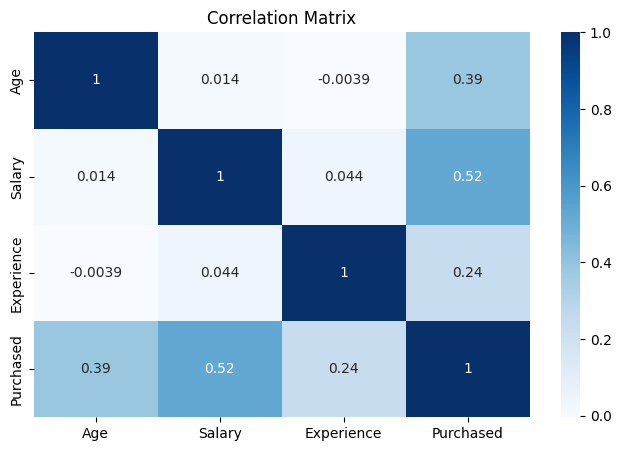

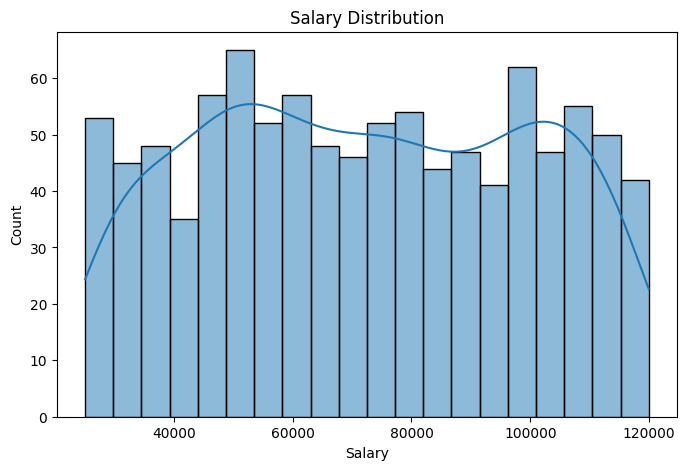


Model Accuracy: 1.00

Feature Importance:
      Feature  Importance
1      Salary    0.490572
0         Age    0.337824
2  Experience    0.171605


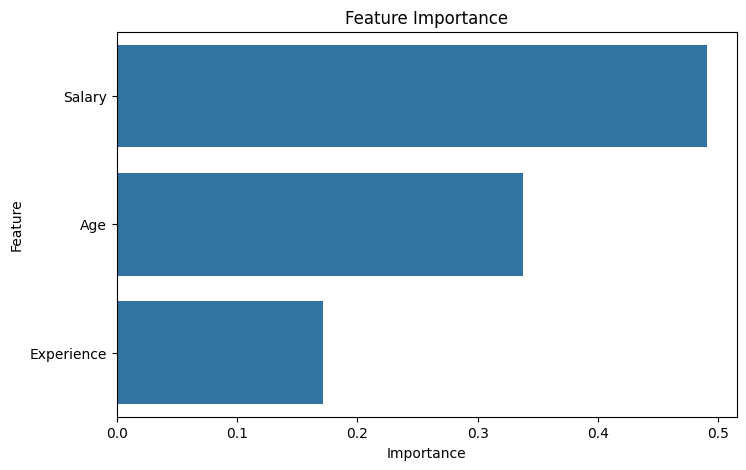

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -----------------------------
# Create Synthetic Dataset
# -----------------------------
np.random.seed(42)

n_samples = 1000

age = np.random.randint(18, 65, n_samples)
salary = np.random.randint(25000, 120000, n_samples)
experience = np.random.randint(0, 40, n_samples)

# Create target variable
purchased = (
    (salary > 60000) &
    (age > 30) &
    (experience > 5)
).astype(int)

# Create DataFrame
df = pd.DataFrame({
    "Age": age,
    "Salary": salary,
    "Experience": experience,
    "Purchased": purchased
})

print("First 5 Records:")
print(df.head())

# -----------------------------
# Exploratory Data Analysis
# -----------------------------
print("\nDataset Statistics:")
print(df.describe())

# Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

# Salary Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Salary"], bins=20, kde=True)
plt.title("Salary Distribution")
plt.show()

# -----------------------------
# Machine Learning
# -----------------------------
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"\nModel Accuracy: {accuracy:.2f}")

# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()